# W5C1: the network reads the review

Type along. One stage per cell.

After the break we switch to the semester project: see `README.md` in this folder.

In [1]:
import pandas as pd

df = pd.read_csv("data/horror_reviews.csv")
df

,film_id,title,year,reviews,scariness
0,s0001,Small Coast,2022,That long hallway shot is chilling. The sound ...,6.9
1,s0002,Long Light,2014,The pacing is gruesome. The cast play it chill...,7.1
2,s0003,Low Hollow,2021,The ending is creepy. I saw it in a full theat...,7.7
3,s0004,Low Field,2011,Every beat is hardly sinister. The score is no...,3.8
4,s0005,The Market,2004,Every beat is unsettling. The ending is eerie....,8.4
...,...,...,...,...,...
1195,s1196,Cold Station II,2018,The middle hour is brutal. The third act is un...,7.8
1196,s1197,Low Market Returns',2021,The final scene is sinister. The cast is doing...,7.4
1197,s1198,Deep Tower,2016,The pacing is unsettling. That long hallway sh...,5.3
1198,s1199,Old Signal III,2018,"I saw it in a full theatre, which helped.",5.2


In [10]:
import re

tokens_per_review = [re.findall(r"[a-z]+", r.lower()) for r in df['reviews']]
vocab = set()
for tokens in tokens_per_review:
    for t in tokens:
        vocab.add(t)
vocab = sorted(vocab)

stoi = {}
for i, token in enumerate(vocab):
    stoi[token] = i+1

stoi

{'a': 1,
 'act': 2,
 'an': 3,
 'and': 4,
 'atmosphere': 5,
 'audience': 6,
 'away': 7,
 'beat': 8,
 'bloody': 9,
 'boring': 10,
 'brutal': 11,
 'cast': 12,
 'chilling': 13,
 'clearly': 14,
 'creepy': 15,
 'design': 16,
 'director': 17,
 'doing': 18,
 'eerie': 19,
 'ending': 20,
 'especially': 21,
 'every': 22,
 'final': 23,
 'first': 24,
 'full': 25,
 'genre': 26,
 'gives': 27,
 'gory': 28,
 'grisly': 29,
 'gruesome': 30,
 'half': 31,
 'hallway': 32,
 'hardly': 33,
 'haunting': 34,
 'helped': 35,
 'here': 36,
 'hour': 37,
 'i': 38,
 'in': 39,
 'is': 40,
 'it': 41,
 'long': 42,
 'lot': 43,
 'loves': 44,
 'middle': 45,
 'minutes': 46,
 'mm': 47,
 'much': 48,
 'never': 49,
 'ninety': 50,
 'no': 51,
 'not': 52,
 'of': 53,
 'ominous': 54,
 'on': 55,
 'once': 56,
 'pacing': 57,
 'padding': 58,
 'play': 59,
 'predictable': 60,
 'premise': 61,
 'real': 62,
 'remotely': 63,
 'saw': 64,
 'scene': 65,
 'score': 66,
 'seeing': 67,
 'shot': 68,
 'shows': 69,
 'silly': 70,
 'sinister': 71,
 'sound':

In [13]:
import torch

L = max(len(t) for t in tokens_per_review)
X = torch.zeros(len(tokens_per_review), L, dtype=torch.long)
for i, t in enumerate(tokens_per_review):
    X[i, L - len(t):] = torch.tensor([stoi[w] for w in t])
y = torch.tensor(df['scariness'].values, dtype=torch.float32)

X.shape

torch.Size([1200, 54])

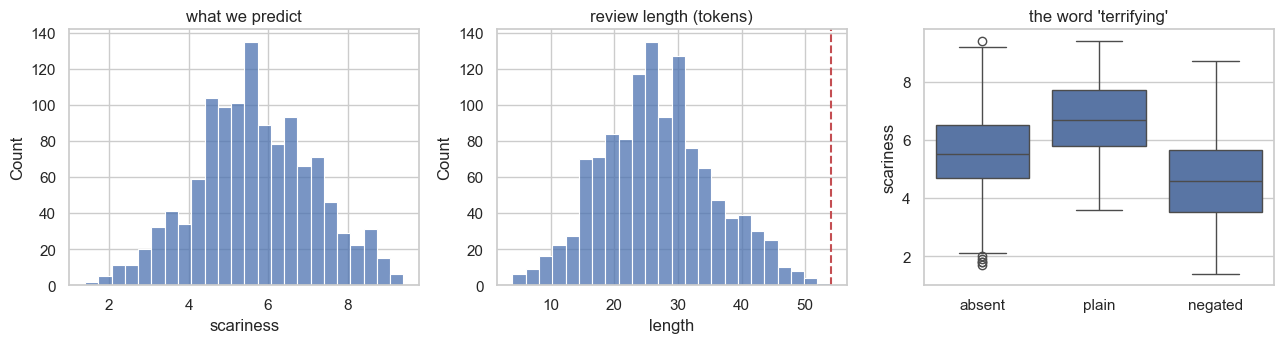

            count  mean
terrifying             
absent        973  5.58
negated        78  4.56
plain         149  6.66


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df["length"] = [len(t) for t in tokens_per_review]
df["terrifying"] = df["reviews"].str.lower().map(
    lambda t: "negated" if re.search(r"(?:not|never|hardly)(?:\s+\w+)?\s+terrifying", t)
    else "plain" if "terrifying" in t else "absent")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
sns.histplot(df, x="scariness", bins=24, ax=ax[0]).set(title="what we predict")
sns.histplot(df, x="length", bins=24, ax=ax[1]).set(title="review length (tokens)")
ax[1].axvline(L, ls="--", color="C3")
sns.boxplot(df, x="terrifying", y="scariness", order=["absent", "plain", "negated"],
            ax=ax[2]).set(title="the word 'terrifying'", xlabel="")
plt.tight_layout()
plt.show()

print(df.groupby("terrifying")["scariness"].agg(["count", "mean"]).round(2))

In [16]:
perm = torch.randperm(len(y), generator=torch.Generator().manual_seed(0))
train_i, test_i = perm[:1000], perm[1000:]
Xtr, ytr = X[train_i], y[train_i]
Xte, yte = X[test_i], y[test_i]

print(Xtr.shape, Xte.shape)

torch.Size([1000, 54]) torch.Size([200, 54])


In [18]:
from torch import nn

class BagOfEmbeddings(nn.Module):
    def __init__(self, V, d=32):
        super().__init__()
        self.emb = nn.Embedding(V, d, padding_idx=0)
        self.out = nn.Linear(d, 1)

    def forward(self, x):
        return self.out(self.emb(x).mean(1)).squeeze(-1)

print(BagOfEmbeddings(len(vocab) + 1))

BagOfEmbeddings(
  (emb): Embedding(90, 32, padding_idx=0)
  (out): Linear(in_features=32, out_features=1, bias=True)
)


In [20]:
def mse(y_pred, y):
    return ((y_pred - y) ** 2).mean()

def train(model, epochs, lr):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    curve = []
    for epoch in range(epochs):
        for i in range(0, len(Xtr), 32):
            pred = model(Xtr[i:i+32])
            gt = ytr[i:i+32]
            loss = mse(pred, gt)
            opt.zero_grad()
            loss.backward()
            opt.step()

        # End of epoch logging
        with torch.no_grad():
            train_pred = model(Xtr)
            valid_pred = model(Xte)
            curve.append({"epoch": epoch, "split": "train",
                          "mse": mse(train_pred, ytr).item()})
            curve.append({"epoch": epoch, "split": "held out",
                          "mse": mse(valid_pred, yte).item()})

    return pd.DataFrame(curve)

torch.manual_seed(0)
bag = BagOfEmbeddings(len(vocab) + 1)
bag_curve = train(bag, 150, 0.01)
bag_curve

,epoch,split,mse
0,0,train,12.372619
1,0,held out,12.332932
2,1,train,4.626846
3,1,held out,4.089043
4,2,train,4.052326
...,...,...,...
295,147,held out,1.416175
296,148,train,1.427439
297,148,held out,1.416108
298,149,train,1.427388


In [21]:
class RNNReader(nn.Module):
    def __init__(self, V, d=32, h=64):
        super().__init__()
        self.emb = nn.Embedding(V, d, padding_idx=0)
        self.rnn = nn.RNN(d, h, batch_first=True)
        self.out = nn.Linear(h, 1)

    def forward(self, x):
        x = self.emb(x)
        x = self.rnn(x)[0].mean(1)
        x = self.out(x)
        return x.squeeze(-1)

torch.manual_seed(0)
rnn = RNNReader(len(vocab) + 1)
rnn_curve = train(rnn, 150, 0.005)
rnn_curve

,epoch,split,mse
0,0,train,2.290136
1,0,held out,2.073321
2,1,train,2.222578
3,1,held out,1.981537
4,2,train,2.219215
...,...,...,...
295,147,held out,0.657289
296,148,train,0.234174
297,148,held out,0.667943
298,149,train,0.253969


In [22]:
Xtr, ytr = X[train_i[:200]], y[train_i[:200]]

torch.manual_seed(0)
starved = RNNReader(len(vocab) + 1)
starved_curve = train(starved, 500, 0.001)
starved_curve

,epoch,split,mse
0,0,train,30.617432
1,0,held out,31.672813
2,1,train,24.852383
3,1,held out,25.760849
4,2,train,13.696232
...,...,...,...
995,497,held out,2.251983
996,498,train,0.144706
997,498,held out,2.227337
998,499,train,0.144522


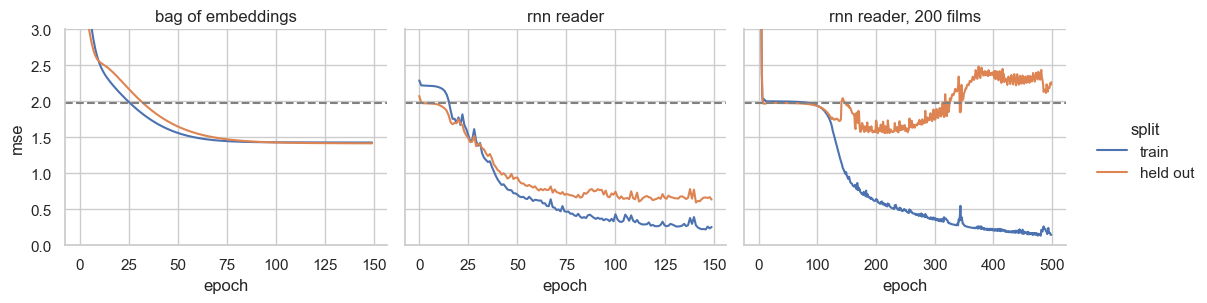

In [26]:
bag_curve['model'] = 'bag of embeddings'
rnn_curve['model'] = 'rnn reader'
starved_curve['model'] = 'rnn reader, 200 films'

curves = pd.concat([bag_curve, rnn_curve, starved_curve], ignore_index=True)

g = sns.relplot(curves, x='epoch', y='mse', hue='split', col='model', 
                kind='line', height=3.2, aspect=1.15, 
                facet_kws={'sharex': False})
g.set(ylim=(0, 3.0))
g.set_titles("{col_name}")
g.refline(y=1.972, color='gray', ls='--')

In [35]:
def score(model, text):
    ids = [stoi[w] for w in re.findall(r'[a-z]+', text.lower()) if w in stoi]
    x = torch.zeros(1, L, dtype=torch.long)
    x[0, L - len(ids):] = torch.tensor(ids)
    with torch.no_grad():
        return model(x).item()

tail = " The pacing is boring. The directory clearly loves the genre. Ninety minutes, no padding"
A = "The ending is terrifying. The score is not gory." + tail
B = "The ending is not terrifying. The score is gory." + tail
for name, text in [('A', A), ('B', B)]:
    bag_score = score(bag, text)
    rnn_score = score(rnn, text)
    print(f"{name}: Bag={bag_score}, RNN={rnn_score}")

A: Bag=6.09857177734375, RNN=5.148191452026367
B: Bag=6.09857177734375, RNN=4.339557647705078
